In [1]:
import pandas as pd
import numpy as np  

data = pd.read_csv('mumbai.csv')

print(data.head())


         time  tavg  tmin  tmax  prcp
0  01-01-1990  23.2  17.0   NaN   0.0
1  02-01-1990  22.2  16.5  29.9   0.0
2  03-01-1990  21.8  16.3  30.7   0.0
3  04-01-1990  25.4  17.9  31.8   0.0
4  05-01-1990  26.5  19.3  33.7   0.0


In [2]:
import pandas as pd

data = pd.read_csv('mumbai.csv')

data['time'] = pd.to_datetime(data['time'], format='%d-%m-%Y')

data = data.dropna()

data['month'] = data['time'].dt.month
data['day'] = data['time'].dt.day
data['year'] = data['time'].dt.year
data['day_of_year'] = data['time'].dt.dayofyear

print(data.head())


        time  tavg  tmin  tmax  prcp  month  day  year  day_of_year
1 1990-01-02  22.2  16.5  29.9   0.0      1    2  1990            2
2 1990-01-03  21.8  16.3  30.7   0.0      1    3  1990            3
3 1990-01-04  25.4  17.9  31.8   0.0      1    4  1990            4
4 1990-01-05  26.5  19.3  33.7   0.0      1    5  1990            5
5 1990-01-06  25.1  19.8  33.5   0.0      1    6  1990            6


In [3]:
import pandas as pd

data = pd.read_csv('mumbai.csv')

data['time'] = pd.to_datetime(data['time'], format='%d-%m-%Y')

data = data.dropna()

data['month'] = data['time'].dt.month
data['day'] = data['time'].dt.day
data['year'] = data['time'].dt.year
data['day_of_year'] = data['time'].dt.dayofyear

print(data.head())


        time  tavg  tmin  tmax  prcp  month  day  year  day_of_year
1 1990-01-02  22.2  16.5  29.9   0.0      1    2  1990            2
2 1990-01-03  21.8  16.3  30.7   0.0      1    3  1990            3
3 1990-01-04  25.4  17.9  31.8   0.0      1    4  1990            4
4 1990-01-05  26.5  19.3  33.7   0.0      1    5  1990            5
5 1990-01-06  25.1  19.8  33.5   0.0      1    6  1990            6


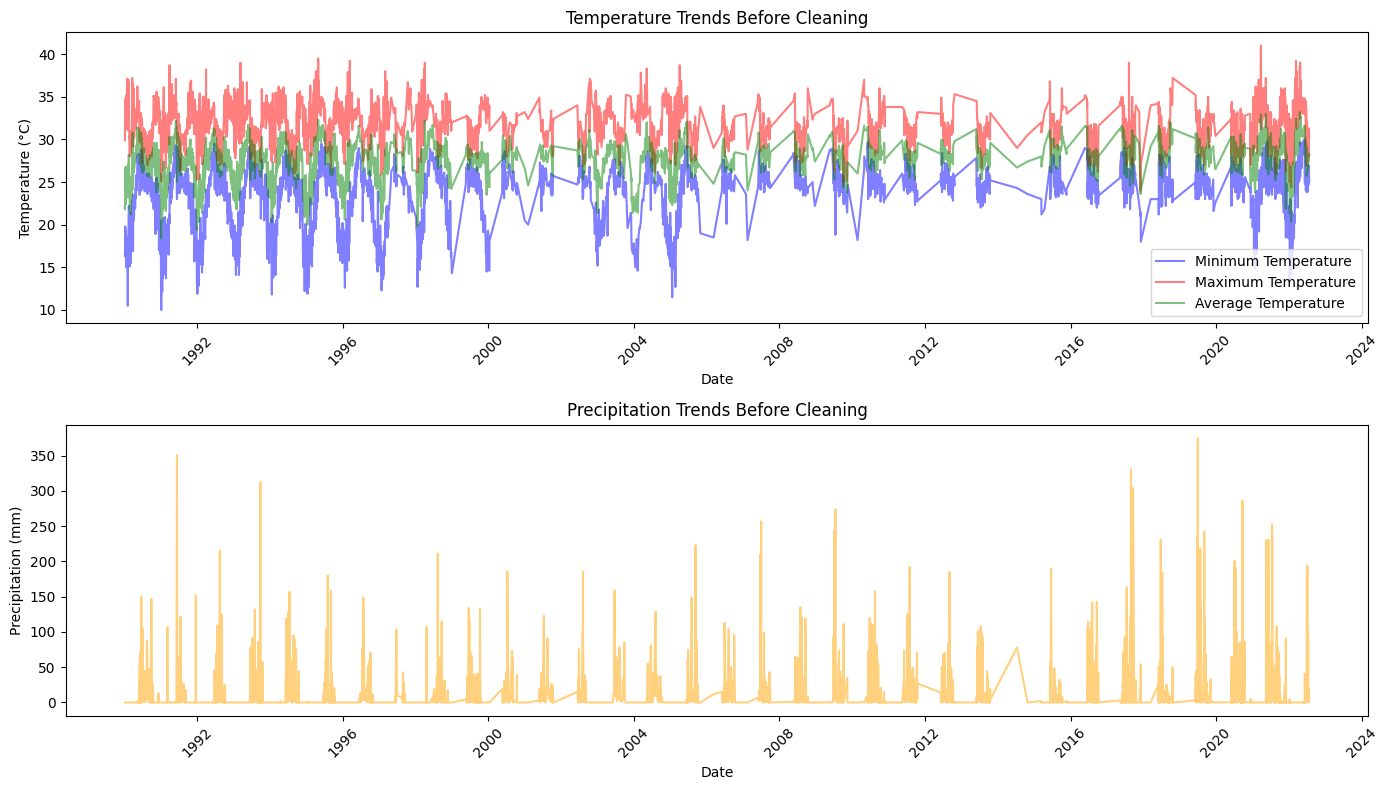

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(data['time'], data['tmin'], label='Minimum Temperature', color='blue', alpha=0.5)
plt.plot(data['time'], data['tmax'], label='Maximum Temperature', color='red', alpha=0.5)
plt.plot(data['time'], data['tavg'], label='Average Temperature', color='green', alpha=0.5)
plt.title('Temperature Trends Before Cleaning')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.xticks(rotation=45)

plt.subplot(2, 1, 2)
plt.plot(data['time'], data['prcp'], color='orange', label='Precipitation', alpha=0.5)
plt.title('Precipitation Trends Before Cleaning')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

features = ['month', 'day', 'year']
target = ['tmin', 'tmax', 'tavg', 'prcp']

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {}
for target_name in target:
    model = LinearRegression()
    model.fit(X_train, y_train[target_name])
    models[target_name] = model

for target_name in target:
    y_pred = models[target_name].predict(X_test)
    mse = mean_squared_error(y_test[target_name], y_pred)
    r2 = r2_score(y_test[target_name], y_pred)
    print(f"{target_name} - Mean Squared Error: {mse:.2f}")
    print(f"{target_name} - R^2 Score: {r2:.2f}")


tmin - Mean Squared Error: 10.11
tmin - R^2 Score: 0.17
tmax - Mean Squared Error: 4.30
tmax - R^2 Score: -0.00
tavg - Mean Squared Error: 3.96
tavg - R^2 Score: 0.11
prcp - Mean Squared Error: 1035.94
prcp - R^2 Score: 0.03


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Mean Squared Error: 263.58
R^2 Score: 0.08


In [7]:
def predict_weather(date_str):

    date = pd.to_datetime(date_str, format='%d-%m-%Y')
    
    month = date.month
    day = date.day
    year = date.year
    
    input_data = np.array([[month, day, year]])
    
    predictions = {}
    for target_name in models:
        predictions[target_name] = models[target_name].predict(input_data)[0]
    
    return predictions

sample_date = '01-06-2025'
print(predict_weather(sample_date))


{'tmin': 24.982776664659553, 'tmax': 31.31205825959148, 'tavg': 28.483275823317243, 'prcp': 18.52034242748232}


c:\Program Files\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
print(data[['tmin', 'tmax', 'tavg', 'prcp']].isna().sum())


tmin    0
tmax    0
tavg    0
prcp    0
dtype: int64


        time  tavg  tmin  tmax  prcp  month  day  year  day_of_year
1 1990-01-02  22.2  16.5  29.9   0.0      1    2  1990            2
2 1990-01-03  21.8  16.3  30.7   0.0      1    3  1990            3
3 1990-01-04  25.4  17.9  31.8   0.0      1    4  1990            4
4 1990-01-05  26.5  19.3  33.7   0.0      1    5  1990            5
5 1990-01-06  25.1  19.8  33.5   0.0      1    6  1990            6


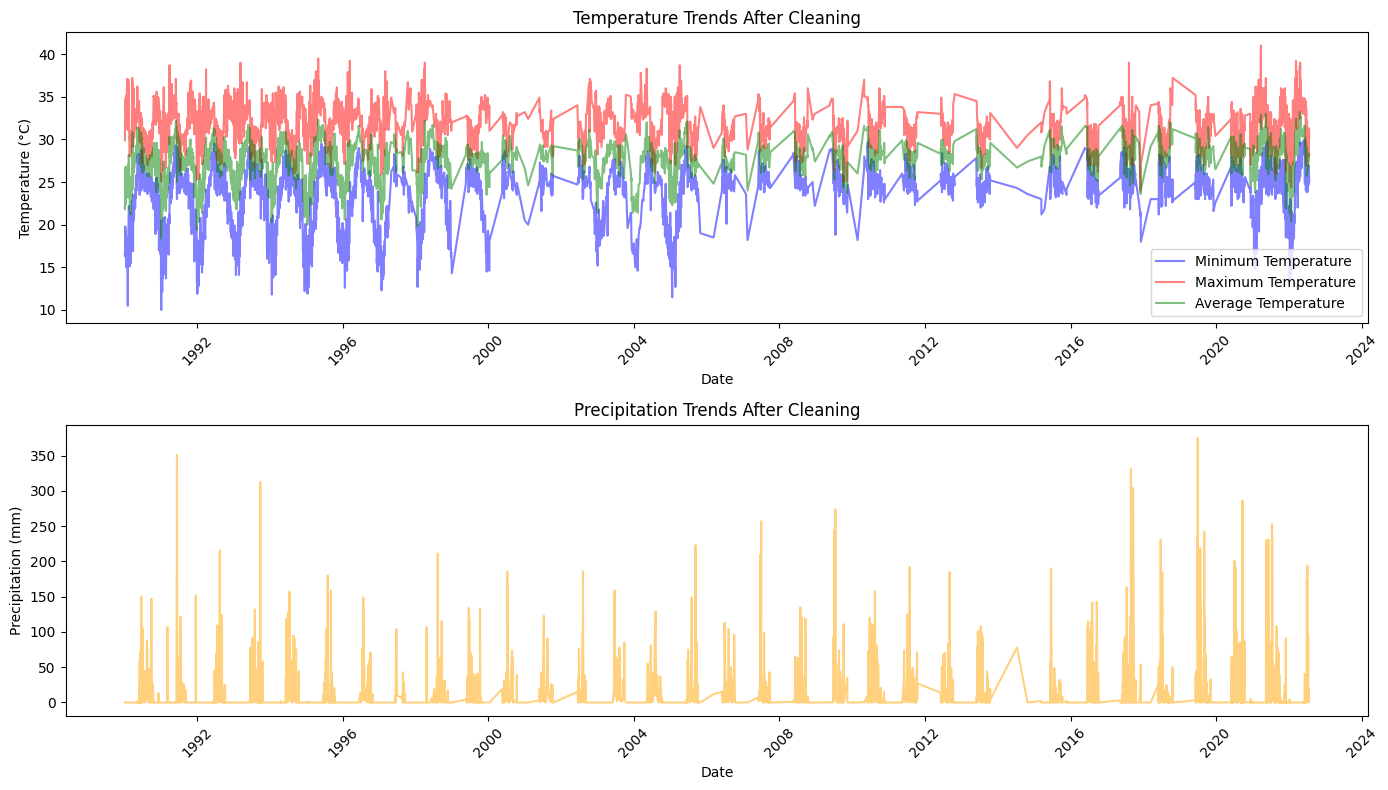

In [9]:

data['month'] = data['time'].dt.month
data['day'] = data['time'].dt.day
data['year'] = data['time'].dt.year
data['day_of_year'] = data['time'].dt.dayofyear

print(data.head())

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(data['time'], data['tmin'], label='Minimum Temperature', color='blue', alpha=0.5)
plt.plot(data['time'], data['tmax'], label='Maximum Temperature', color='red', alpha=0.5)
plt.plot(data['time'], data['tavg'], label='Average Temperature', color='green', alpha=0.5)
plt.title('Temperature Trends After Cleaning')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.xticks(rotation=45)

plt.subplot(2, 1, 2)
plt.plot(data['time'], data['prcp'], color='orange', label='Precipitation', alpha=0.5)
plt.title('Precipitation Trends After Cleaning')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [10]:
data = data.dropna(subset=['tmin', 'tmax', 'tavg', 'prcp'])


In [11]:
data[['tmin', 'tmax', 'tavg', 'prcp']] = data[['tmin', 'tmax', 'tavg', 'prcp']].fillna(data[['tmin', 'tmax', 'tavg', 'prcp']].mean())


In [12]:
import pandas as pd
import pickle
from sklearn.linear_model import LinearRegression

data = pd.read_csv('mumbai.csv')

data['time'] = pd.to_datetime(data['time'], format='%d-%m-%Y')

data['month'] = data['time'].dt.month
data['day'] = data['time'].dt.day
data['year'] = data['time'].dt.year

data = data.dropna(subset=['tmin', 'tmax', 'tavg', 'prcp'])

X = data[['month', 'day', 'year']]
y = data[['tmin', 'tmax', 'tavg', 'prcp']]

model = LinearRegression()
model.fit(X, y)

with open('weather_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as 'weather_model.pkl'")


Model saved as 'weather_model.pkl'
